In [19]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split
import pickle

In [20]:
data_df = pd.read_csv("data.csv", low_memory = False)
data_df.head(10)

,utm_source,utm_medium,utm_campaign,utm_adcontent,device_category,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,event_action
0,149,6,84,244,1,76,259200,6,117,2374,0
1,77,15,39,263,1,145,328790,46,117,1346,0
2,149,6,84,244,1,76,259200,6,117,1047,0
3,210,14,-1,68,1,191,308898,6,117,1346,0
4,210,14,-1,-1,1,191,308898,6,117,1346,0
5,210,31,87,45,1,10,304500,44,117,1811,0
6,116,14,39,57,2,103,619458,50,117,1811,0
7,149,6,84,45,1,145,230400,6,117,1811,0
8,149,6,84,244,1,10,329160,44,117,1346,0
9,149,6,84,45,1,145,376980,6,117,1346,0


In [21]:
X = data_df.drop('event_action', axis=1)
y = data_df['event_action']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.33, random_state = 42, stratify=y
)

In [22]:
model = CatBoostClassifier(
    iterations = 1000,
    learning_rate = 0.1,
    l2_leaf_reg = 0.2,
    auto_class_weights = 'Balanced'
)

model.fit(
    X = X_train,
    y = y_train
)

0:	learn: 0.6851347	total: 61.7ms	remaining: 1m 1s
1:	learn: 0.6800797	total: 113ms	remaining: 56.1s
2:	learn: 0.6747182	total: 171ms	remaining: 56.7s
3:	learn: 0.6701100	total: 215ms	remaining: 53.5s
4:	learn: 0.6660600	total: 267ms	remaining: 53.2s
5:	learn: 0.6634265	total: 318ms	remaining: 52.7s
6:	learn: 0.6603341	total: 359ms	remaining: 51s
7:	learn: 0.6581853	total: 415ms	remaining: 51.5s
8:	learn: 0.6554877	total: 462ms	remaining: 50.8s
9:	learn: 0.6533275	total: 500ms	remaining: 49.5s
10:	learn: 0.6519781	total: 536ms	remaining: 48.2s
11:	learn: 0.6501434	total: 568ms	remaining: 46.7s
12:	learn: 0.6484152	total: 606ms	remaining: 46s
13:	learn: 0.6468136	total: 641ms	remaining: 45.1s
14:	learn: 0.6456872	total: 672ms	remaining: 44.1s
15:	learn: 0.6445069	total: 704ms	remaining: 43.3s
16:	learn: 0.6435293	total: 736ms	remaining: 42.6s
17:	learn: 0.6422689	total: 772ms	remaining: 42.1s
18:	learn: 0.6412148	total: 808ms	remaining: 41.7s
19:	learn: 0.6402734	total: 842ms	remaining:

In [23]:
model.feature_importances_

array([11.51393232,  6.22141403, 13.28334388,  7.68527184,  1.26302948,
        9.26390357, 16.91270746,  6.52390706,  6.42461178, 20.90787859])

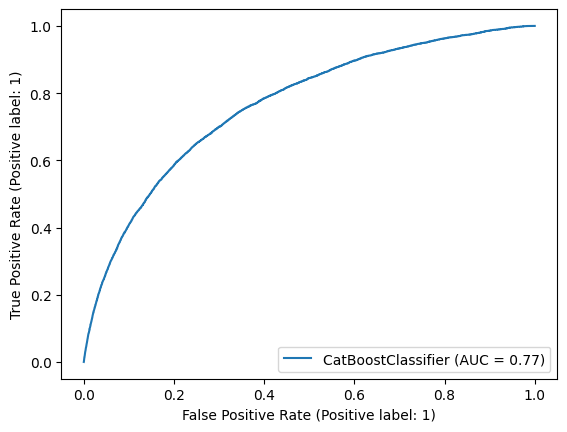

In [24]:
RocCurveDisplay.from_estimator(
    model, 
    X=X_test,
    y=y_test
)

In [25]:
def model_predict(input_layer): 
    print(f'Prediction: {model.predict(input_layer)}')

In [26]:
model_predict(data_df.iloc[59, :])

Prediction: 1


In [27]:
with open('model.pickle', 'wb') as f: 
    pickle.dump(model, f)